# `BranchedRate`

Consider the CNO cycle:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(,e^+\nu){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

To represent this in a network, we would need 6 nuclei.  For approximate networks used for stellar evolution, we often want fewer nuclei.

The MESA `basic.net` network represents this using only 2
nuclei, by breaking it into 2 sequences:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(,e^+\nu){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}$$

$${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

We can represent the first sequence using {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>`, using the first rate of the sequence as the overall rate, and giving:

$${}^{12}\mathrm{C}(pp,e^+\nu){}^{14}\mathrm{N}$$

For the second sequence however, we have a problem that there is another branch,

$${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}$$

So we need to approximate this as well.  We can do this with a {py:obj}`BranchedRate <pynucastro.rates.branched_rate.BranchedRate>`.

A `BranchedRate` takes a rate to use as the underlying rate for the sequence, ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ in our case, as well as the rates representing the different branches for the endpoint.

Expressing the values of these rates as:

* underlying rate: $\lambda_{{}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}}$
* branch I: $\lambda_{{}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}}$
* branch II: $\lambda_{{}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}}$

then we can express the effective rates for the two sequences as:

* branch I: ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$

  $$\lambda_{{}^{14}\mathrm{N}(pp,e^+\nu\alpha){}^{12}\mathrm{C}} = \lambda_{{}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}} \frac{\lambda_{{}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}}}{\lambda_{{}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}} + \lambda_{{}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}}}$$

* branch II: ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}$

  $$\lambda_{{}^{14}\mathrm{N}(pp,e^+\nu){}^{16}\mathrm{O}} = \lambda_{{}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}} \frac{\lambda_{{}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}}}{\lambda_{{}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}} + \lambda_{{}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}}}$$

where each branched is normalized by its branching ratio.  This is what a `BranchedRate` will do automatically for us.

To complete this chain, we should also include

$${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}(,e^+,\nu){}^{17}\mathrm{O}(p,\alpha){}^{14}\mathrm{N}$$

which we can do using a `ModifiedRate`

## Reference CNO network

We'll start by making a CNO network with all nuclei present (as well as ${}^{16}\mathrm{O}$ and the nuclei involved in ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}(,e^+,\nu){}^{17}\mathrm{O}(p,\alpha){}^{14}\mathrm{N}$)

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4", "c12", "c13", "n13", "n14", "n15",
                           "o15", "o16", "o17", "F17"],
                          tabular_ordering=["ffn", "oda"],
                          with_reverse=False)

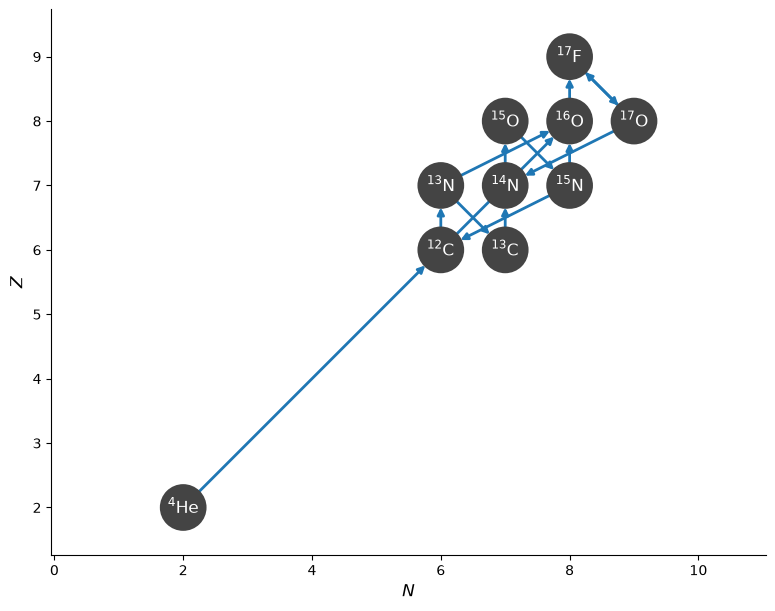

In [3]:
fig = net.plot()

We see that this also has ${}^{12}\mathrm{C}(\alpha, \gamma){}^{16}\mathrm{O}$ and 3-$\alpha$, but we will work at temperatures where we don't expect these to be dominant.

In [4]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 11
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 14

  rates explicitly connecting nuclei: 14
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 2
  approximate rates: 0
  derived rates: 0
  branched rates: 0
  modified rates: 0
  custom rates: 0


Now we can integrate it.

In [5]:
rho = 100
T = 2.e7
comp = pyna.Composition(net.unique_nuclei, init="solar")

In [6]:
tmax = 1.e20

In [7]:
sol = net.integrate_network(tmax, rho, T, comp)

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:485: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


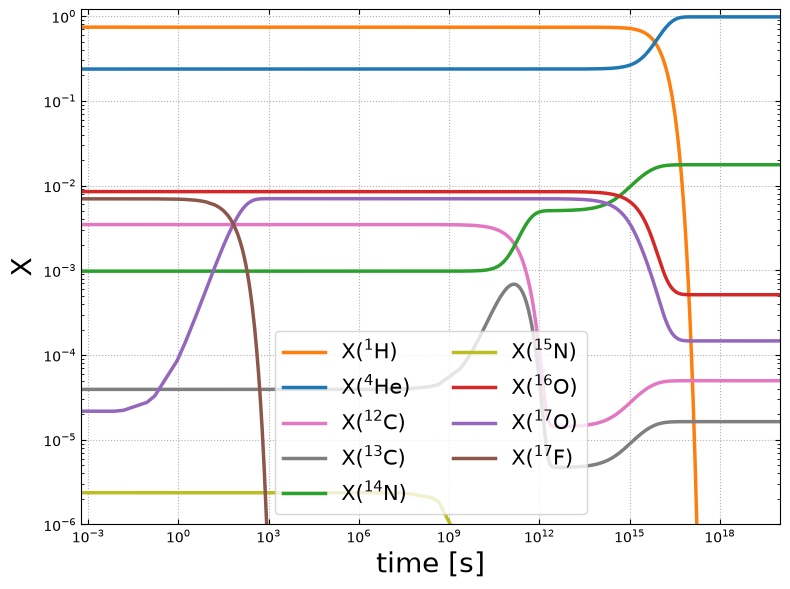

In [8]:
fig = sol.plot_evolution(ymin=1.e-6)

## Reduced network

Now we'll setup a reduced CNO network using the approximations described above.

In [9]:
rl = pyna.ReacLibLibrary()

In [10]:
rc12pg = rl.get_rate_by_name("c12(p,g)n13")
rn14pg = rl.get_rate_by_name("n14(p,g)o15")
rn15pa = rl.get_rate_by_name("n15(p,a)c12")
rn15pg = rl.get_rate_by_name("n15(p,g)o16")
ro16pg = rl.get_rate_by_name("o16(p,g)f17")

### ${}^{12}\mathrm{C} + 2 p \rightarrow {}^{14}\mathrm{N}$

Our first rate sequence will be approximated as a `ModifiedRate`

In [11]:
from pynucastro import Nucleus

In [12]:
rc12_2p_n14 = pyna.ModifiedRate(rc12pg,
                                new_products=[Nucleus("n14")],
                                stoichiometry={Nucleus("p"): 2})

In [13]:
rc12_2p_n14

C12 + p + p ⟶ N14 + e⁺ + 𝜈

### ${}^{14}\mathrm{N} + 2 p$ branches

When we construct a `BranchedRate`, we need to specify
the underlying rate (assumed to be the first in the sequence), the branch we are taking (`primary_branch`)
and the other possible branch (`other_branch`).  

If there are more reactants in the sequence than given in the
first rate, then we need to specify the stoichiometry.

In [14]:
rn14_2p_c12 = pyna.BranchedRate(rn14pg,
                                primary_branch=rn15pa,
                                other_branch=rn15pg,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,a)C12")

In [15]:
rn14_2p_c12

N14 + p + p ⟶ He4 + C12 + e⁺ + 𝜈

Also notice that it is recognized as being a weak reaction:

In [16]:
rn14_2p_c12.weak

True

Now we can look at the function that will be used to evaluate this rate:

In [17]:
print(rn14_2p_c12.function_string_py())

@numba.njit()
def p_N14_to_He4_C12_branched(rate_eval, tf, log_scor=0.0):
    # N14 + p + p --> He4 + C12
    # represents the sequence: N14(p,g)O15(,e+nu)N15(p,a)C12

    r0 = rate_eval.p_N14_to_O15_reaclib
    r_prim_br = rate_eval.p_N15_to_He4_C12_reaclib
    r_other_br = rate_eval.p_N15_to_O16_reaclib

    f = r_prim_br / (r_prim_br + r_other_br)
    rate_eval.p_N14_to_He4_C12_branched = f * r0




We see that, as desired, the rate is taken to be the underlying rate modified by the branching ratio represented by the primary branch.

Now let's do the alternate branch:

In [18]:
rn14_2p_o16 = pyna.BranchedRate(rn14pg,
                                primary_branch=rn15pg,
                                other_branch=rn15pa,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,g)O16")

In [19]:
rn14_2p_o16

N14 + p + p ⟶ O16 + e⁺ + 𝜈

### ${}^{16}\mathrm{O} + 2 p \rightarrow {}^{14}\mathrm{N} + \alpha$

In [20]:
ro16_2p_n14_a = pyna.ModifiedRate(ro16pg,
                                  new_products=[Nucleus("n14"),
                                                Nucleus("he4")],
                                  stoichiometry={Nucleus("p"): 2})

In [21]:
ro16_2p_n14_a

O16 + p + p ⟶ N14 + He4 + e⁺ + 𝜈

Now we can create a network.  We'll also add 3-$\alpha$ and ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$

In [22]:
r3a = rl.get_rate_by_name("he4(aa,g)c12")
rc12ag = rl.get_rate_by_name("c12(a,g)o16")

In [23]:
net_reduced = pyna.PythonNetwork(rates=[rc12_2p_n14,
                                        rn14_2p_c12,
                                        rn14_2p_o16,
                                        ro16_2p_n14_a,
                                        r3a, rc12ag])

In [24]:
net_reduced.summary()

Network summary
---------------
  explicitly carried nuclei: 5
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 11

  rates explicitly connecting nuclei: 6
  hidden rates: 5

  reaclib rates: 7
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 0
  branched rates: 2
  modified rates: 2
  custom rates: 0


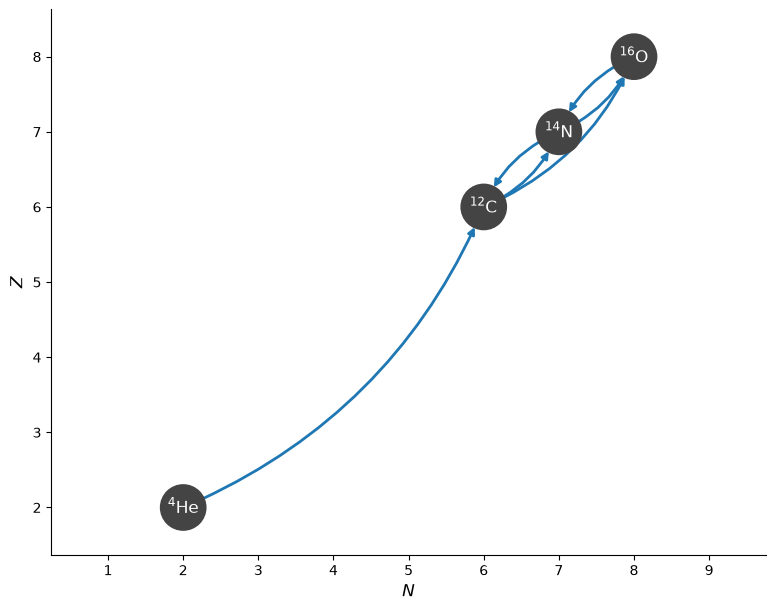

In [25]:
fig = net_reduced.plot(curved_edges=True)

Now we'll integrate it.  We need a new composition for this because there is a different set of nuclei

In [26]:
comp_reduced = pyna.Composition(net_reduced.unique_nuclei, init="solar")

In [27]:
sol_reduced = net_reduced.integrate_network(tmax, rho, T, comp_reduced)

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:485: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


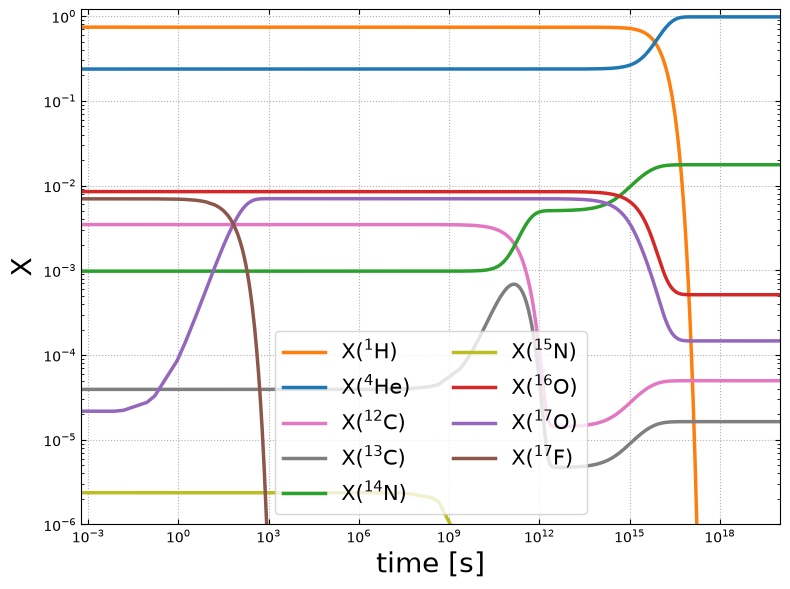

In [28]:
fig = sol.plot_evolution(ymin=1.e-6)

We can see what the righthand side function looks like by writing it out and importing it

In [29]:
net_reduced.write_network("reduced.py")

In [30]:
import reduced

In [31]:
import inspect
print(inspect.getsource(reduced.rhs_eq))

@numba.njit()
def rhs_eq(t, Y, rho, T, screen_func):

    rate_eval = do_rate_eval(t, Y, rho, T, screen_func)
    dYdt = np.zeros((nnuc), dtype=np.float64)

    dYdt[jp] = (
          + -2*rho*Y[jp]*Y[jc12]*rate_eval.p_C12_to_N14_modified  +
          + -2*rho*Y[jp]*Y[jn14]*rate_eval.p_N14_to_He4_C12_branched  +
          + -2*rho*Y[jp]*Y[jn14]*rate_eval.p_N14_to_O16_branched  +
          + -2*rho*Y[jp]*Y[jo16]*rate_eval.p_O16_to_N14_He4_modified
       )

    dYdt[jhe4] = (
          +rho*Y[jp]*Y[jn14]*rate_eval.p_N14_to_He4_C12_branched  +
          +rho*Y[jp]*Y[jo16]*rate_eval.p_O16_to_N14_He4_modified  +
          + -3*1.66666666666667e-01*rho**2*Y[jhe4]**3*rate_eval.He4_He4_He4_to_C12_reaclib  +
          -rho*Y[jhe4]*Y[jc12]*rate_eval.He4_C12_to_O16_reaclib
       )

    dYdt[jc12] = (
          -rho*Y[jp]*Y[jc12]*rate_eval.p_C12_to_N14_modified  +
          +rho*Y[jp]*Y[jn14]*rate_eval.p_N14_to_He4_C12_branched  +
          +1.66666666666667e-01*rho**2*Y[jhe4]**3*rate_eval.He4_H

Looking at the evolution for ${}^{14}\mathrm{N}$ (`dYdt[jn14]`), we see that ${}^{14}\mathrm{N}$ is consumed by both branched rates.  And we see the corresponding creation in the ${}^4\mathrm{He}$, ${}^{12}\mathrm{C}$, and ${}^{16}\mathrm{O}$ evolution equations.

Similarly, if we look at protons (`dYdt[jp]`) we see that 2 protons are consumed for each branched rate, but the rate depends on `Y[jp]` and not `Y[jp]**2`.  This is the desired dependence---it is not a three body reaction.

## Comparison

Now we can compare the reduced CNO approximation to the network integration with the full CNO

In [32]:
import matplotlib.pyplot as plt

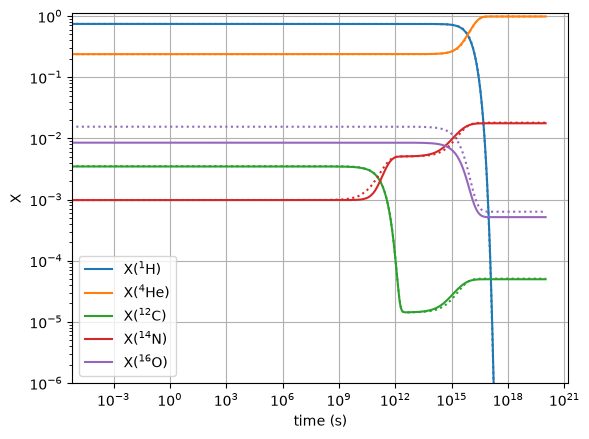

In [33]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_reduced.unique_nuclei):
    ax.loglog(sol_reduced.t, sol_reduced.X[i, :],
              linestyle=":", color=f"C{i}")    
    idx = sol.unique_nuclei.index(nuc)
    ax.loglog(sol.t, sol.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-6, 1.1)

ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend()
ax.grid()

Here we see that the overall trends are similar, but the reduced CNO network consumes the H slightly faster than the full network.